# Improve the Fair Model

Let's push R² above 0.93 with better features and tuning:

In [27]:
import pandas as pd
import numpy as np
import ast
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import joblib

## Add Richer Features


In [28]:
df = pd.read_csv("./data/magnet_features.csv")

--- Ratio features ---


In [29]:
df["sites_per_element"]     = df["nsites"] / df["nelements"]
df["mag_sites_ratio"]       = df["num_magnetic_sites"] / df["nsites"]
df["volume_per_site"]       = df["volume"] / df["nsites"]
df["density_x_mag_sites"]   = df["density"] * df["num_magnetic_sites"]

--- Rare earth flag ---

In [30]:
rare_earths = ["Nd", "Sm", "Gd", "Eu", "Tb", "Dy", "Ho", "Er", "Pr", "La", "Ce"]
def parse_elements(e):
    try:
        return ast.literal_eval(e)
    except:
        return []

df["elements_list"] = df["elements"].apply(parse_elements)
df["has_rare_earth"] = df["elements_list"].apply(
    lambda x: int(any(re in x for re in rare_earths))
)

--- Transition metal count ---

In [ ]:
transition_metals = ["Fe", "Co", "Ni", "Mn", "Cr", "V", "Cu", "Ti", "Zn"]
df["num_transition_metals"] = df["elements_list"].apply(
    lambda x: sum(1 for e in x if e in transition_metals)
)

df.to_csv("./data/magnet_features_v2.csv", index=False)
print("New features added!")
print(df[["formula", "mag_sites_ratio", "has_rare_earth", "num_transition_metals"]].head())

New features added!
          formula  mag_sites_ratio  has_rare_earth  num_transition_metals
0         AcCeMg2         0.250000               1                      0
1           AcEu3         0.750000               1                      0
2          AcMgO3         0.600000               0                      0
3       Ag(AuF4)2         0.090909               0                      0
4  Ag14H8I4(OF2)5         0.048780               0                      0


## Retrain with Improved Features


In [32]:
feature_cols_v2 = [
    # Original
    "nelements", "nsites", "volume", "density",
    "energy_above_hull", "formation_energy", "band_gap",
    "num_magnetic_sites", "crystal_system_enc",
    "has_Fe", "has_Co", "has_Ni", "has_Mn",
    "has_Nd", "has_Sm", "has_Gd", "has_Eu", "has_O", "has_Li",
    # New engineered features
    "sites_per_element", "mag_sites_ratio",
    "volume_per_site", "density_x_mag_sites",
    "has_rare_earth", "num_transition_metals"
]

X2 = df[feature_cols_v2]
y2 = df["log_magnetization"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

Random Forest Regressor

In [33]:
rf2 = RandomForestRegressor(n_estimators=300, max_depth=None,
                             min_samples_leaf=1, random_state=42, n_jobs=-1)
rf2.fit(X_train2, y_train2)
pred2 = rf2.predict(X_test2)

r2_v2  = r2_score(y_test2, pred2)
mae_v2 = mean_absolute_error(np.expm1(y_test2), np.expm1(pred2))
print(f"RF v2 → R²: {r2_v2:.4f} | MAE: {mae_v2:.2f} μB")

RF v2 → R²: 0.8903 | MAE: 2.36 μB


## Try Gradient Boosting Too


In [34]:
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                max_depth=5, random_state=42)
gb.fit(X_train2, y_train2)
pred_gb = gb.predict(X_test2)

print(f"GradBoost   → R²: {r2_score(y_test2, pred_gb):.4f} | MAE: {mean_absolute_error(np.expm1(y_test2), np.expm1(pred_gb)):.2f} μB")

# Final comparison
print(f"\n{'Model':<30} {'R²':>8} {'MAE (μB)':>12}")
print("-" * 52)
print(f"{'RF Fair (original)':<30} {'0.8817':>8} {'2.49':>12}")
print(f"{'RF v2 (engineered)':<30} {r2_v2:>8.4f} {mae_v2:>12.2f}")
print(f"{'GradientBoosting v2':<30} {r2_score(y_test2, pred_gb):>8.4f} {mean_absolute_error(np.expm1(y_test2), np.expm1(pred_gb)):>12.2f}")

GradBoost   → R²: 0.8646 | MAE: 3.04 μB

Model                                R²     MAE (μB)
----------------------------------------------------
RF Fair (original)               0.8817         2.49
RF v2 (engineered)               0.8903         2.36
GradientBoosting v2              0.8646         3.04


## Prediction vs Actual Plot

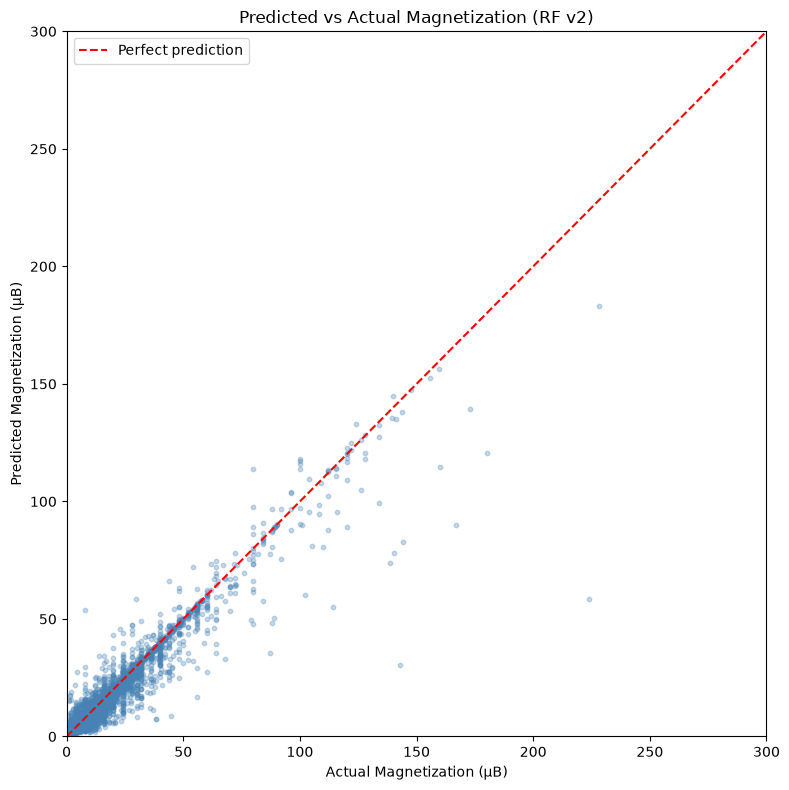

In [35]:
y_actual = np.expm1(y_test2)
y_predicted = np.expm1(pred2)

plt.figure(figsize=(8, 8))
plt.scatter(y_actual, y_predicted, alpha=0.3, s=10, color="steelblue")
plt.plot([0, 300], [0, 300], "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual Magnetization (μB)")
plt.ylabel("Predicted Magnetization (μB)")
plt.title("Predicted vs Actual Magnetization (RF v2)")
plt.legend()
plt.xlim(0, 300)
plt.ylim(0, 300)
plt.tight_layout()
plt.savefig("./figure/pred_vs_actual.png", dpi=150)
plt.show()

## 🚀 Final Push — Try XGBoost + Hyperparameter Tuning

In [36]:
# XGBoost with better hyperparameters
xgb2 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb2.fit(X_train2, y_train2,
         eval_set=[(X_test2, y_test2)],
         verbose=False)

pred_xgb2 = xgb2.predict(X_test2)
r2_xgb2  = r2_score(y_test2, pred_xgb2)
mae_xgb2 = mean_absolute_error(np.expm1(y_test2), np.expm1(pred_xgb2))
print(f"XGBoost v2  → R²: {r2_xgb2:.4f} | MAE: {mae_xgb2:.2f} μB")

# Final summary
print(f"\n{'Model':<30} {'R²':>8} {'MAE (μB)':>12}")
print("-" * 52)
print(f"{'RF Fair (original)':<30} {'0.8817':>8} {'2.49':>12}")
print(f"{'RF v2 (engineered)':<30} {r2_v2:>8.4f} {mae_v2:>12.2f}")
print(f"{'GradientBoosting v2':<30} {'0.8646':>8} {'3.04':>12}")
print(f"{'XGBoost v2 (tuned)':<30} {r2_xgb2:>8.4f} {mae_xgb2:>12.2f}")

XGBoost v2  → R²: 0.8871 | MAE: 2.68 μB

Model                                R²     MAE (μB)
----------------------------------------------------
RF Fair (original)               0.8817         2.49
RF v2 (engineered)               0.8903         2.36
GradientBoosting v2              0.8646         3.04
XGBoost v2 (tuned)               0.8871         2.68


## 💾 Save the Best Model

In [37]:
joblib.dump(rf2, "./models/magnet_model_rf_v2.pkl")
joblib.dump(feature_cols_v2, "./models/feature_cols_v2.pkl")

print("✅ Models saved!")

✅ Models saved!
